In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

import joblib

pd.set_option("display.max_columns", None)

In [2]:
import plotly.express as px
import folium
import shap


c:\Users\srujan18\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("P:\Radio-Link-Degradation-Prediction\signal_metrics.csv")
df.head()

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,2023-05-05 12:50:40.000000,Anisabad,25.599109,85.137355,-84.274113,0.0,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,2023-05-05 12:53:47.210173,Fraser Road,25.433286,85.070053,-97.653121,0.0,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892
2,2023-05-05 12:56:54.420346,Boring Canal Road,25.498809,85.211371,-87.046134,0.0,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070
3,2023-05-05 13:00:01.630519,Danapur,25.735138,85.208400,-94.143159,0.0,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698
4,2023-05-05 13:03:08.840692,Phulwari Sharif,25.538556,85.159860,-94.564765,0.0,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16829 entries, 0 to 16828
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     16829 non-null  object 
 1   Locality                      16829 non-null  object 
 2   Latitude                      16829 non-null  float64
 3   Longitude                     16829 non-null  float64
 4   Signal Strength (dBm)         16829 non-null  float64
 5   Signal Quality (%)            16829 non-null  float64
 6   Data Throughput (Mbps)        16829 non-null  float64
 7   Latency (ms)                  16829 non-null  float64
 8   Network Type                  16829 non-null  object 
 9   BB60C Measurement (dBm)       16829 non-null  float64
 10  srsRAN Measurement (dBm)      16829 non-null  float64
 11  BladeRFxA9 Measurement (dBm)  16829 non-null  float64
dtypes: float64(9), object(3)
memory usage: 1.5+ MB


In [5]:
df.shape

(16829, 12)

In [6]:
df.describe()


,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
count,16829.000000,16829.000000,16829.000000,16829.0,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000
mean,25.594796,85.137314,-90.072484,0.0,16.182856,101.313624,-68.820150,-74.439562,-68.819930
std,0.089881,0.090095,5.399368,0.0,25.702734,56.010418,40.046739,43.215204,39.996934
min,25.414575,84.957936,-116.942267,0.0,1.000423,10.019527,-115.667514,-124.652054,-119.207545
25%,25.522858,85.064124,-93.615962,0.0,2.001749,50.320775,-94.021959,-101.249987,-93.749032
50%,25.595383,85.138149,-89.665566,0.0,2.997175,100.264318,-89.126942,-96.838442,-89.282746
75%,25.667620,85.209504,-86.145491,0.0,9.956314,149.951112,0.000000,0.000000,0.000000
max,25.773648,85.316994,-74.644848,0.0,99.985831,199.991081,0.000000,0.000000,0.000000


In [7]:
df.isnull().sum()

Timestamp                       0
Locality                        0
Latitude                        0
Longitude                       0
Signal Strength (dBm)           0
Signal Quality (%)              0
Data Throughput (Mbps)          0
Latency (ms)                    0
Network Type                    0
BB60C Measurement (dBm)         0
srsRAN Measurement (dBm)        0
BladeRFxA9 Measurement (dBm)    0
dtype: int64

In [8]:
df.drop("Signal Quality (%)", axis=1, inplace=True)

In [12]:
print(df.columns.tolist())

['Timestamp', 'Locality', 'Latitude', 'Longitude', 'Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)', 'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)']


In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [10]:
df["Hour"] = df["Timestamp"].dt.hour

df["Day"] = df["Timestamp"].dt.day

df["Month"] = df["Timestamp"].dt.month

df["Weekday"] = df["Timestamp"].dt.dayofweek

In [11]:
df["Throughput_Efficiency"] = (
    df["Data Throughput (Mbps)"]
    /
    (df["Latency (ms)"] + 1)
)

In [13]:
df["Measurement_Avg"] = (
    df["BB60C Measurement (dBm)"] +
    df["srsRAN Measurement (dBm)"] +
    df["BladeRFxA9 Measurement (dBm)"]
) / 3

In [14]:
signal_score = (
    (df["Signal Strength (dBm)"] + 120)
    /
    70
) * 100

In [15]:
latency_score = (
    1 -
    (
        df["Latency (ms)"]
        /
        df["Latency (ms)"].max()
    )
) * 100

In [16]:
throughput_score = (
    df["Data Throughput (Mbps)"]
    /
    df["Data Throughput (Mbps)"].max()
) * 100

In [17]:
df["Health_Score"] = (
    0.4 * signal_score +
    0.3 * latency_score +
    0.3 * throughput_score
)

In [18]:
df["Health_Score"].describe()

count    16829.000000
mean        36.759261
std         13.305844
min         12.403623
25%         26.660348
50%         34.110952
75%         42.889748
max         76.343860
Name: Health_Score, dtype: float64

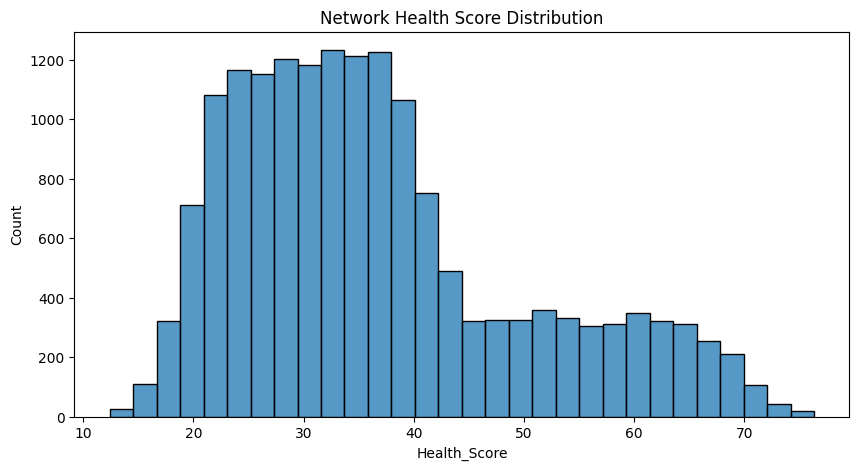

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Health_Score"],
    bins=30
)

plt.title("Network Health Score Distribution")

plt.show()

In [20]:
network_encoder = LabelEncoder()

df["Network Type"] = network_encoder.fit_transform(
    df["Network Type"]
)

In [21]:
features = [

    "Signal Strength (dBm)",

    "Data Throughput (Mbps)",

    "Latency (ms)",

    "Network Type",

    "Latitude",

    "Longitude",

    "Hour",

    "Throughput_Efficiency",

    "Signal_Latency_Ratio",

    "Measurement_Avg"
]

In [22]:
X = df[features]

y = df["Health_Score"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = XGBRegressor(

    n_estimators=500,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [25]:
predictions = model.predict(X_test)

In [26]:
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)

print("R2 :", r2)

MAE : 0.13005020749596577
R2 : 0.9997917823461681


In [27]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
7,Throughput_Efficiency,0.689037
1,Data Throughput (Mbps),0.133068
2,Latency (ms),0.127214
3,Network Type,0.022680
0,Signal Strength (dBm),0.011882
8,Signal_Latency_Ratio,0.010150
9,Measurement_Avg,0.005918
5,Longitude,0.000017
6,Hour,0.000017
4,Latitude,0.000017


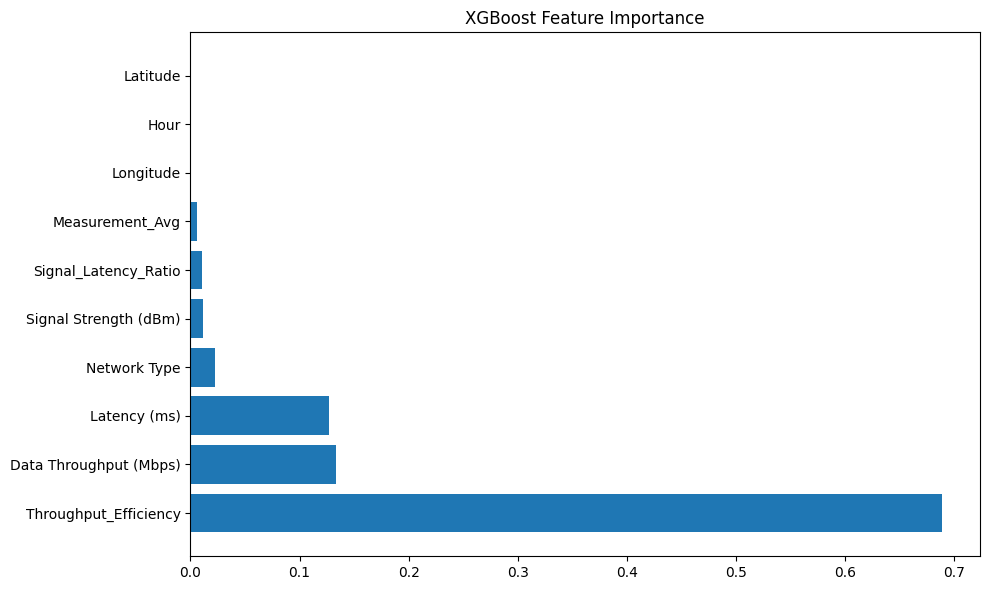

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()

In [29]:
def get_status(score):

    if score >= 60:
        return "Healthy"

    elif score >= 40:
        return "Warning"

    else:
        return "Critical"

In [30]:
def recommendation(score):

    if score >= 60:
        return "Network operating normally."

    elif score >= 40:
        return "Monitor throughput and latency."

    else:
        return "Immediate network investigation required."

In [32]:
df.to_csv(
    "cleaned_network_data.csv",
    index=False
)

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

mape = mean_absolute_percentage_error(
    y_test,
    predictions
) * 100

print("=" * 50)
print("XGBoost Model Evaluation")
print("=" * 50)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

XGBoost Model Evaluation
MAE  : 0.1301
MSE  : 0.0375
RMSE : 0.1938
R²   : 0.9998
MAPE : 0.36%


In [34]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison["Error"] = (
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Error
0,63.193505,62.974022,0.219483
1,39.175191,39.200218,-0.025027
2,40.251894,40.405704,-0.153811
3,23.236717,23.217278,0.019440
4,41.338899,41.553307,-0.214408
5,34.561769,34.485424,0.076345
6,67.268471,67.140999,0.127472
7,44.947848,44.759285,0.188563
8,57.239746,56.870506,0.369240
9,59.672424,59.947521,-0.275097


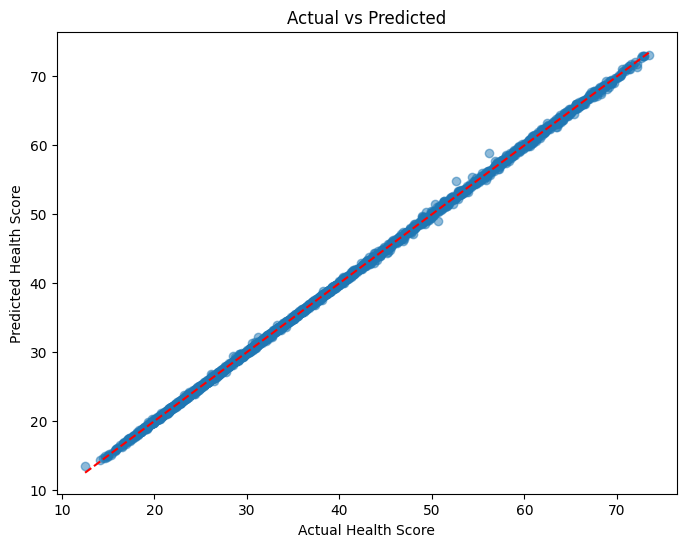

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Health Score")
plt.ylabel("Predicted Health Score")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [36]:
top_features = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(top_features)

                  Feature  Importance
7   Throughput_Efficiency    0.689037
1  Data Throughput (Mbps)    0.133068
2            Latency (ms)    0.127214
3            Network Type    0.022680
0   Signal Strength (dBm)    0.011882
8    Signal_Latency_Ratio    0.010150
9         Measurement_Avg    0.005918
5               Longitude    0.000017
6                    Hour    0.000017
4                Latitude    0.000017


In [37]:
worst_localities = (
    df.groupby("Locality")["Health_Score"]
      .mean()
      .sort_values()
      .head(10)
)

best_localities = (
    df.groupby("Locality")["Health_Score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

In [38]:
network_stats = (
    df.groupby("Network Type")
      .agg({
          "Data Throughput (Mbps)": "mean",
          "Latency (ms)": "mean",
          "Health_Score": "mean"
      })
      .round(2)
)

network_stats

,Data Throughput (Mbps),Latency (ms),Health_Score
Network Type,,,
0,2.01,149.41,28.18
1,6.50,74.85,37.77
2,54.58,29.86,56.10
3,1.99,150.50,25.17


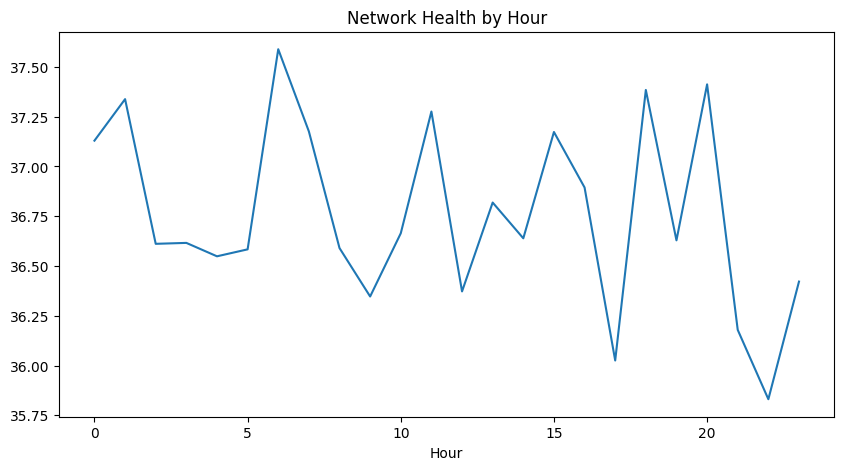

In [39]:
hourly_stats = (
    df.groupby("Hour")["Health_Score"]
      .mean()
)

hourly_stats.plot(figsize=(10,5))
plt.title("Network Health by Hour")
plt.show()

In [41]:
def predict_network_health(
    signal_strength,
    throughput,
    latency,
    network_type,
    latitude,
    longitude,
    hour,
    bb60c,
    srsran,
    bladerf
):
    
    measurement_avg = (
        bb60c +
        srsran +
        bladerf
    ) / 3

    throughput_efficiency = (
        throughput /
        (latency + 1)
    )

    signal_latency_ratio = (
        abs(signal_strength) /
        (latency + 1)
    )

    network_type = network_encoder.transform(
        [network_type]
    )[0]

    input_data = pd.DataFrame({
        "Signal Strength (dBm)":[signal_strength],
        "Data Throughput (Mbps)":[throughput],
        "Latency (ms)":[latency],
        "Network Type":[network_type],
        "Latitude":[latitude],
        "Longitude":[longitude],
        "Hour":[hour],
        "Throughput_Efficiency":[throughput_efficiency],
        "Signal_Latency_Ratio":[signal_latency_ratio],
        "Measurement_Avg":[measurement_avg]
    })

    score = model.predict(input_data)[0]

    return score

In [42]:
sample_score = predict_network_health(
    signal_strength=-85,
    throughput=120,
    latency=40,
    network_type="5G",
    latitude=17.3850,
    longitude=78.4867,
    hour=14,
    bb60c=-82,
    srsran=-84,
    bladerf=-83
)

print("Predicted Health Score:", round(sample_score, 2))

Predicted Health Score: 74.49


In [43]:
def get_status(score):

    if score >= 60:
        return "Healthy"

    elif score >= 40:
        return "Warning"

    else:
        return "Critical"

In [44]:
def get_recommendation(score):

    if score >= 60:
        return "Network operating normally."

    elif score >= 40:
        return "Monitor throughput and latency."

    else:
        return "Immediate network investigation recommended."

In [45]:
print("=" * 50)

print("Network Health Score:",
      round(sample_score, 2))

print("Status:",
      get_status(sample_score))

print("Recommendation:",
      get_recommendation(sample_score))

print("=" * 50)

Network Health Score: 74.49
Status: Healthy
Recommendation: Network operating normally.


In [48]:
import joblib

joblib.dump(model, "model.pkl")

joblib.dump(
    network_encoder,
    "network_encoder.pkl"
)

joblib.dump(
    features,
    "feature_columns.pkl"
)

print("All files saved successfully!")

All files saved successfully!


In [49]:
print(network_encoder.classes_)

['3G' '4G' '5G' 'LTE']


In [50]:
preds = model.predict(X_test)

print("Min:", preds.min())
print("Max:", preds.max())
print("Mean:", preds.mean())

Min: 13.474802
Max: 73.112526
Mean: 36.794285


In [51]:
feature_columns = joblib.load("feature_columns.pkl")

print(feature_columns)

['Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)', 'Network Type', 'Latitude', 'Longitude', 'Hour', 'Throughput_Efficiency', 'Signal_Latency_Ratio', 'Measurement_Avg']


In [55]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

                  Feature  Importance
7   Throughput_Efficiency    0.689037
1  Data Throughput (Mbps)    0.133068
2            Latency (ms)    0.127214
3            Network Type    0.022680
0   Signal Strength (dBm)    0.011882
8    Signal_Latency_Ratio    0.010150
9         Measurement_Avg    0.005918
5               Longitude    0.000017
6                    Hour    0.000017
4                Latitude    0.000017


In [56]:
import pandas as pd

df1 = pd.read_csv("cleaned_network_data.csv")
print(df1.columns.tolist())

['Timestamp', 'Locality', 'Latitude', 'Longitude', 'Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)', 'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)', 'Hour', 'Day', 'Month', 'Weekday', 'Throughput_Efficiency', 'Signal_Latency_Ratio', 'Measurement_Avg', 'Health_Score']


In [57]:
import pandas as pd

imp = pd.read_csv("feature_importance.csv")
print(imp.head())
print(imp.columns.tolist())

                  Feature  Importance
0   Throughput_Efficiency    0.689037
1  Data Throughput (Mbps)    0.133068
2            Latency (ms)    0.127214
3            Network Type    0.022680
4   Signal Strength (dBm)    0.011882
['Feature', 'Importance']
